# Basic Plan
Make a variable that keeps track of the round that we are on. If today's date is after the next round load the next round and then use a script to get the points from the df. We will have to keep track of each qualifying, race, sprint qualifying, and sprint race. The goal is to plot each driver's fantasy points according to the f1 fantasy rules.

In [1]:
import fastf1
import pandas as pd
import time
from datetime import date, datetime

In [2]:
# Here is how we get today's date
today = date.today()
print(today)


2026-04-04


In [4]:
# # Here is how you get the date of each race day
# schedule = fastf1.get_event_schedule(2026)
# event = schedule.get_event_by_round(4)
# event["EventDate"].date() #< today

In [5]:
for i in range(1, 6):
    print(event[f'Session{i}'], event[f'Session{i}Date'])

Practice 1 2026-05-01 12:30:00-04:00
Sprint Qualifying 2026-05-01 16:30:00-04:00
Sprint 2026-05-02 12:00:00-04:00
Qualifying 2026-05-02 16:00:00-04:00
Race 2026-05-03 16:00:00-04:00


In [6]:

# For now we are going to just manually 
# get the session and maybe return to scheduled jobs later


session = fastf1.get_session(2026, 1, "Q")
session.load()
results = session.results.reset_index(drop = True, inplace = True)

# The columns I need for scoring are the driver, team, points, status
results_df = session.results[["Abbreviation", "TeamName","Q1","Q2","Q3"]]
results_df.index = results_df.index + 1

core           INFO 	Loading data for Australian Grand Prix - Qualifying [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	No lap data for driver 18
core        WARNING 	No lap data for driver 55
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 18)
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 55)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 22 drivers: ['63', '12', '6', '16', '81', '1', '44', '30', '41', '5', '27', '87', '31', '10', '23', '43', '14', '11', '77', '18', 

In [7]:
results_df


,Abbreviation,TeamName,Q1,Q2,Q3
1,RUS,Mercedes,0 days 00:01:19.507000,0 days 00:01:18.934000,0 days 00:01:18.518000
2,ANT,Mercedes,0 days 00:01:20.120000,0 days 00:01:19.435000,0 days 00:01:18.811000
3,HAD,Red Bull Racing,0 days 00:01:20.023000,0 days 00:01:19.653000,0 days 00:01:19.303000
4,LEC,Ferrari,0 days 00:01:20.226000,0 days 00:01:19.357000,0 days 00:01:19.327000
5,PIA,McLaren,0 days 00:01:19.664000,0 days 00:01:19.525000,0 days 00:01:19.380000
6,NOR,McLaren,0 days 00:01:20.010000,0 days 00:01:19.882000,0 days 00:01:19.475000
7,HAM,Ferrari,0 days 00:01:19.811000,0 days 00:01:19.921000,0 days 00:01:19.478000
8,LAW,Racing Bulls,0 days 00:01:20.491000,0 days 00:01:20.144000,0 days 00:01:19.994000
9,LIN,Racing Bulls,0 days 00:01:20.409000,0 days 00:01:19.971000,0 days 00:01:21.247000
10,BOR,Audi,0 days 00:01:20.495000,0 days 00:01:20.221000,NaT


In [8]:

drivers_score = {}
for row in results_df.itertuples():
    if not pd.isnull(row.Q1):
        drivers_score[row.Abbreviation] = row.Index
    else:
        drivers_score[row.Abbreviation] = "NC/DSQ"
drivers_score

{'RUS': 1,
 'ANT': 2,
 'HAD': 3,
 'LEC': 4,
 'PIA': 5,
 'NOR': 6,
 'HAM': 7,
 'LAW': 8,
 'LIN': 9,
 'BOR': 10,
 'HUL': 11,
 'BEA': 12,
 'OCO': 13,
 'GAS': 14,
 'ALB': 15,
 'COL': 16,
 'ALO': 17,
 'PER': 18,
 'BOT': 19,
 'STR': 'NC/DSQ',
 'VER': 'NC/DSQ',
 'SAI': 'NC/DSQ'}

In [ ]:
# # Here is how you get the date of each race day
# schedule = fastf1.get_event_schedule(2026)
# event = schedule.get_event_by_round(4)
# event["EventDate"].date() #< today

datetime.date(2026, 5, 3)

In [28]:
# results["Points"].plot(kind = "bar")
# plt.show()

In [21]:
# time1 = time.time()
# for row in results.itertuples():
#     print(row.Index, row.Abbreviation, row.Points)
# time2 = time.time()
# time2-time1

In [22]:
# time1 = time.time()
# for index, row in results.iterrows():
#     print(index, row["Abbreviation"], row["Points"])
# time2 = time.time()
# time2-time1

In [29]:
driver_score = {}
for row in results_df.itertuples():
    driver_score[row.Abbreviation] = row.Points
driver_score

AttributeError: 'Pandas' object has no attribute 'Points'

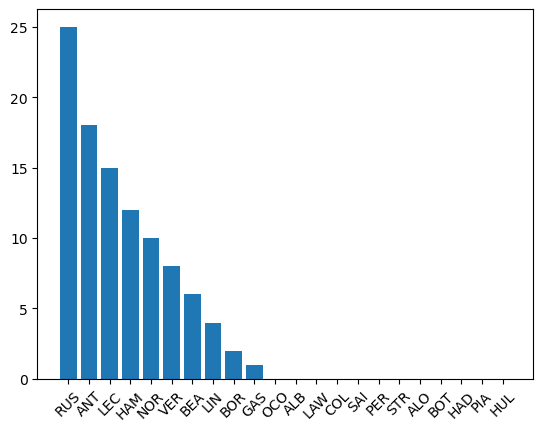

In [32]:
x = driver_score.keys()
y = driver_score.values()

fig, ax = plt.subplots()
ax.bar(x,y)
ax.tick_params(axis = 'x', rotation = 45)

In [17]:
qualifying = {1: 'RUS',
 2: 'ANT',
 3: 'HAD',
 4: 'LEC',
 5: 'PIA',
 6: 'NOR',
 7: 'HAM',
 8: 'LAW',
 9: 'LIN',
 10: 'BOR',
 11: 'HUL',
 12: 'BEA',
 13: 'OCO',
 14: 'GAS',
 15: 'ALB',
 16: 'COL',
 17: 'ALO',
 18: 'PER',
 19: 'BOT',
 20: 'STR',
 21: 'VER',
 22: 'SAI'}

qualifying.keys()

dict_keys([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22])